# Exploration, Identification and Evaluation of most relevant features for the detection of malicious Android applications using machine learning models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

# Configuration
%matplotlib inline
sns.set_theme(style="whitegrid")

c:\Users\info\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\info\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Data import, cleaning, and visualisation

In [2]:
dataset_path = 'dataset.csv'
df = pd.read_csv(dataset_path , na_values="?")

def clean_data(data):
  # Delete features with only one value
  data = data.loc[:, data.nunique() > 1]

  # Fill empty values with 0
  data = data.fillna(0)

  # Encodage target (Malware = 1, Benign = 0)
  le = LabelEncoder()
  data['class'] = le.fit_transform(data['class'])

  return data

df_cleaned = clean_data(df)
print(f"Dimensions after cleaning : {df_cleaned.shape}")

Dimensions after cleaning : (15036, 216)


## Features analyze

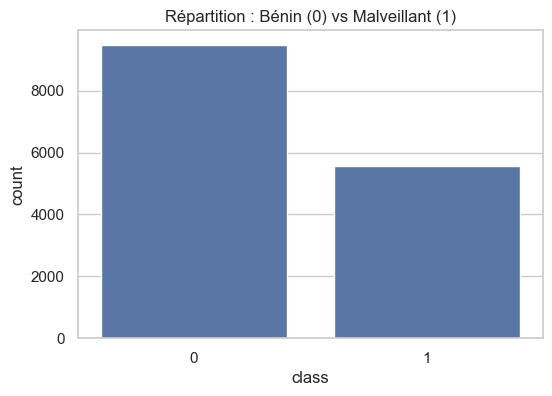

Text(0.5, 1.0, 'Top 10 Features corrélées au Malware')

In [3]:

# Distribution of classes
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df_cleaned)
plt.title('Répartition : Bénin (0) vs Malveillant (1)')
plt.show()

# Heatmap of 10 features on the most correlated to the target
top_corr = df_cleaned.corr()['class'].sort_values(ascending=False).head(11)
sns.heatmap(df_cleaned[top_corr.index].corr(), annot=True, cmap='RdYlGn')
plt.title('Top 10 Features corrélées au Malware')

## Most relevant features identification

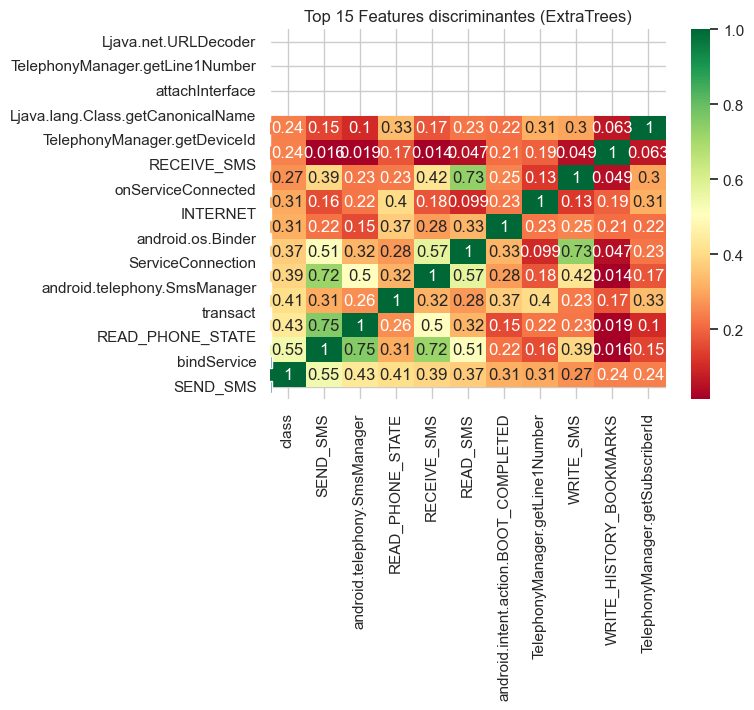

In [4]:
X = df_cleaned.drop('class', axis=1)
y = df_cleaned['class']

# Approach 1 : Get importance via Trees (ExtraTrees)
model_fi = ExtraTreesClassifier(n_estimators=100)
model_fi.fit(X, y)

feat_importances = pd.Series(model_fi.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 Features discriminantes (ExtraTrees)')
plt.show()

# Approach 2 : Filter statistics (Mutual Information)
# Useful to catch non-linear relations
mi_score = mutual_info_classif(X, y)
mi_series = pd.Series(mi_score, index=X.columns)

## Split dataset for training and test

In [5]:
# Split : 70% Train, 15% Validation, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardisation (necessary for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Training and evaluations

In [6]:
models = {
  "Random Forest": RandomForestClassifier(n_estimators=100),
  "SVM": SVC(kernel='linear', probability=True)
}

results = {}

for name, model in models.items():
  # Training
  model.fit(X_train_scaled, y_train)

  # Prediction
  y_pred = model.predict(X_test_scaled)
  
  # Metrics
  results[name] = {
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred)
  }
  
  print(f"--- {name} ---")
  print(confusion_matrix(y_test, y_pred))
  print(classification_report(y_test, y_pred))

--- Random Forest ---
[[1402    8]
 [  24  822]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1410
           1       0.99      0.97      0.98       846

    accuracy                           0.99      2256
   macro avg       0.99      0.98      0.98      2256
weighted avg       0.99      0.99      0.99      2256

--- SVM ---
[[1383   27]
 [  26  820]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1410
           1       0.97      0.97      0.97       846

    accuracy                           0.98      2256
   macro avg       0.97      0.98      0.97      2256
weighted avg       0.98      0.98      0.98      2256



## Results and discussions

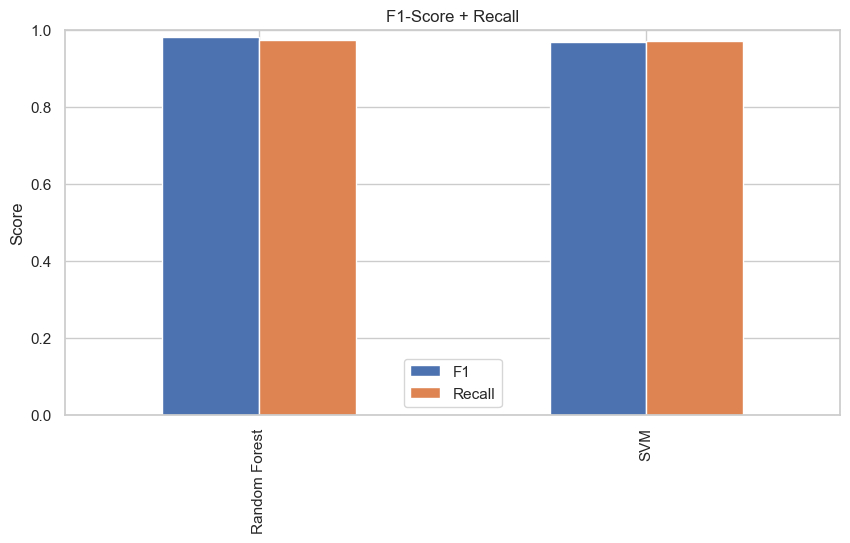

Features recommanded for final model : ['SEND_SMS', 'bindService', 'READ_PHONE_STATE', 'transact', 'android.telephony.SmsManager', 'ServiceConnection', 'android.os.Binder', 'INTERNET', 'onServiceConnected', 'RECEIVE_SMS', 'TelephonyManager.getDeviceId', 'Ljava.lang.Class.getCanonicalName', 'attachInterface', 'TelephonyManager.getLine1Number', 'Ljava.net.URLDecoder', 'READ_SMS', 'android.intent.action.BOOT_COMPLETED', 'TelephonyManager.getSubscriberId', 'Landroid.content.Context.unregisterReceiver', 'chmod']


In [7]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5))
plt.title('F1-Score + Recall')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.show()

# Saving features identified as "key features"
important_features = feat_importances.nlargest(20).index.tolist()
print(f"Features recommanded for final model : {important_features}")